 análise comparativa do desempenho de diferentes modelos de LLMs na prova do POSCOMP 2019.

In [54]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path


In [54]:
#organização dos gráficos

plt.style.use('default')
sns.set_palette("pastel")
%matplotlib inline

dir_graficos = Path.cwd() / 'graficos'
dir_graficos.mkdir(exist_ok=True)

subpastas = ["01_desempenho_geral", "02_desempenho_por_assunto", "03_desempenho_por_conteudo"
""]
for subpasta in subpastas:
    (dir_graficos / subpasta).mkdir(exist_ok=True)


In [55]:

df = pd.read_excel('resultados.xlsx')
print(df.head())
print(df.info())

df_2019 = df[df['Ano'] == 2019].copy()

   ID  Questão  Gabarito     Assunto   Ano GPT 5 Gemini Claude Sonnet 4  \
0   1         1        A  Matemática  2019     A      A               A   
1   2         2        B  Matemática  2019     B      B               B   
2   3         3        D  Matemática  2019     D      D               D   
3   4         4        E  Matemática  2019     E      E               E   
4   5         5        E  Matemática  2019     E      E               E   

  Deepseek v3.1 Contem Imagem Contem Formula Contem Tabela Contem Codigo  
0             A             0              1             0             0  
1             B             0              1             0             0  
2             D             0              1             0             0  
3             E             0              1             0             0  
4             E             0              1             0             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 13 colu

GPT 5: 62/70 = 88.57%
Gemini: 59/70 = 84.29%
Claude Sonnet 4: 61/70 = 87.14%
Deepseek v3.1: 64/70 = 91.43%


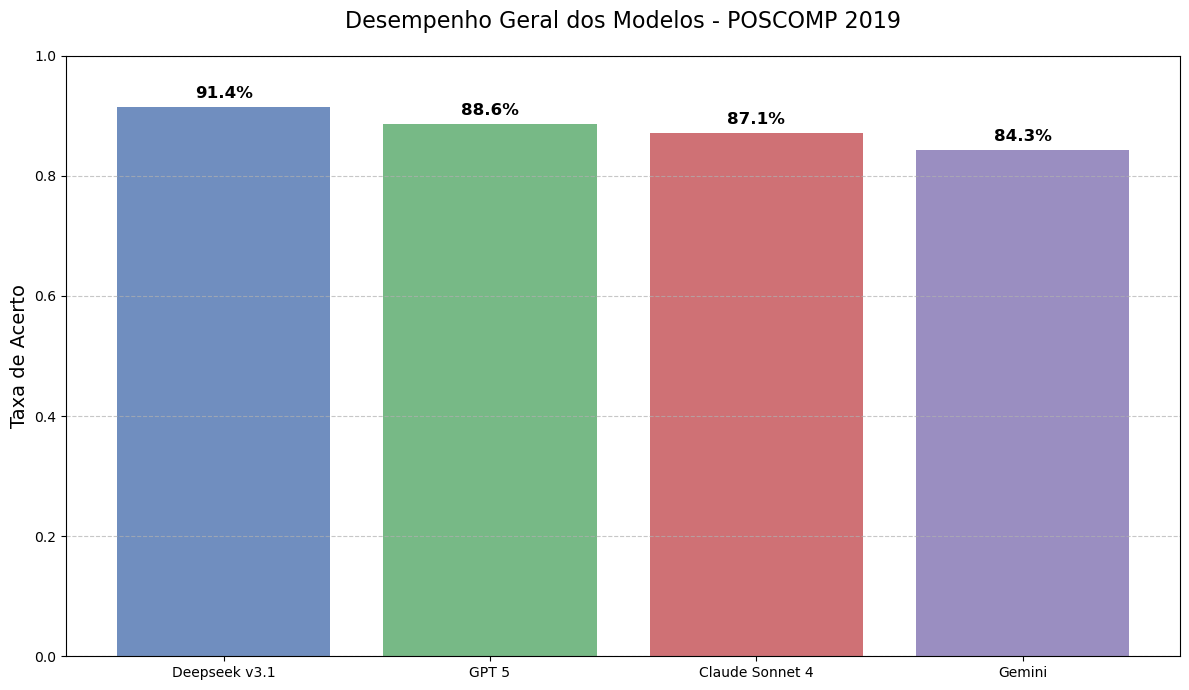

In [56]:
modelos = ['GPT 5', 'Gemini', 'Claude Sonnet 4', 'Deepseek v3.1']

#desempenho geral

desempenho = {}
for modelo in modelos:
    acertos = (df_2019[modelo] == df_2019['Gabarito']).sum()
    total = len(df_2019)
    desempenho[modelo] = acertos / total
    print(f"{modelo}: {acertos}/{total} = {desempenho[modelo]:.2%}")


plt.figure(figsize=(12, 7))
modelos_ordenados = sorted(desempenho, key=desempenho.get, reverse=True)
valores_ordenados = [desempenho[m] for m in modelos_ordenados]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = plt.bar(modelos_ordenados, valores_ordenados, color=colors, alpha=0.8)
plt.ylabel('Taxa de Acerto', fontsize=14)
plt.title('Desempenho Geral dos Modelos - POSCOMP 2019', fontsize=16, pad=20)
plt.ylim(0, 1)


for bar, valor in zip(bars, valores_ordenados):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{valor:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig( dir_graficos / '01_desempenho_geral' / 'desempenho_geral_2019.png', 
            dpi=300, bbox_inches='tight')
plt.savefig( dir_graficos / '01_desempenho_geral' / 'desempenho_geral_2019.pdf', 
            bbox_inches='tight')
plt.show()


ANÁLISE POR ASSUNTO

Assunto: Matemática (20 questões)
  GPT 5: 19/20 = 95.00%
  Gemini: 17/20 = 85.00%
  Claude Sonnet 4: 20/20 = 100.00%
  Deepseek v3.1: 20/20 = 100.00%

Assunto: Fundamentos da Computação (30 questões)
  GPT 5: 26/30 = 86.67%
  Gemini: 25/30 = 83.33%
  Claude Sonnet 4: 25/30 = 83.33%
  Deepseek v3.1: 26/30 = 86.67%

Assunto: Tecnologia de Computadores (20 questões)
  GPT 5: 17/20 = 85.00%
  Gemini: 17/20 = 85.00%
  Claude Sonnet 4: 16/20 = 80.00%
  Deepseek v3.1: 18/20 = 90.00%


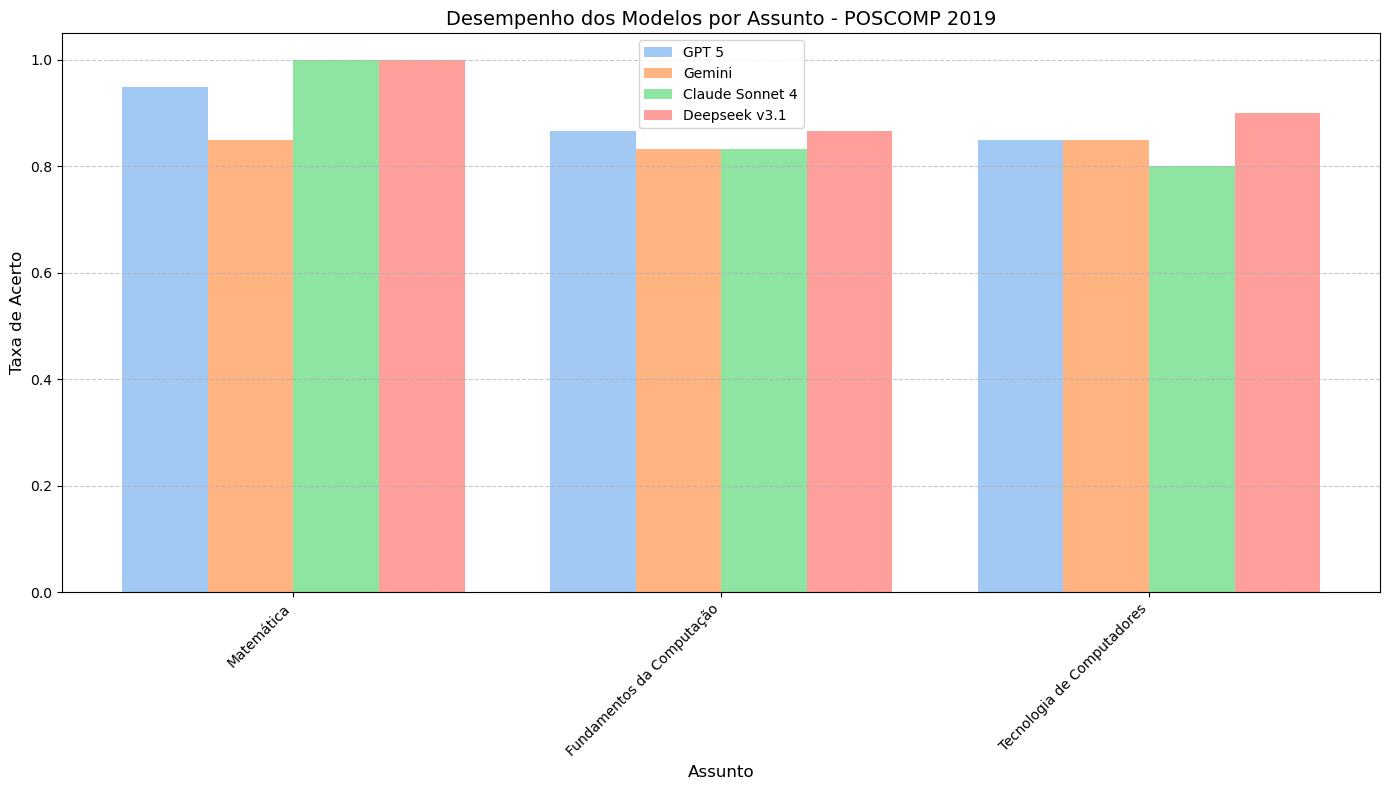

In [57]:
# por assunto
print("\n" + "="*60)
print("ANÁLISE POR ASSUNTO")
print("="*60)

assuntos = df_2019['Assunto'].unique()
desempenho_assuntos = pd.DataFrame(index=assuntos, columns=modelos)
contagem_assuntos = {}

for assunto in assuntos:
    subset = df_2019[df_2019['Assunto'] == assunto]
    contagem_assuntos[assunto] = len(subset)
    print(f"\nAssunto: {assunto} ({len(subset)} questões)")
    for modelo in modelos:
        acertos = (subset[modelo] == subset['Gabarito']).sum()
        taxa = acertos / len(subset)
        desempenho_assuntos.loc[assunto, modelo] = taxa
        print(f"  {modelo}: {acertos}/{len(subset)} = {taxa:.2%}")


plt.figure(figsize=(14, 8))
x = np.arange(len(assuntos))
width = 0.2

for i, modelo in enumerate(modelos):
    plt.bar(x + i*width, desempenho_assuntos[modelo].values, width, label=modelo)

plt.xlabel('Assunto', fontsize=12)
plt.ylabel('Taxa de Acerto', fontsize=12)
plt.title('Desempenho dos Modelos por Assunto - POSCOMP 2019', fontsize=14)
plt.xticks(x + width*1.5, assuntos, rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '02_desempenho_por_assunto' / 'desempenho_assuntos_barras.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '02_desempenho_por_assunto' / 'desempenho_assuntos_barras.pdf', 
            bbox_inches='tight')
plt.show()



ANÁLISE POR TIPO DE CONTEÚDO

Tipo: Imagem (3 questões)
  GPT 5: 2/3 = 66.67%
  Gemini: 0/3 = 0.00%
  Claude Sonnet 4: 1/3 = 33.33%
  Deepseek v3.1: 2/3 = 66.67%

Tipo: Fórmula (20 questões)
  GPT 5: 20/20 = 100.00%
  Gemini: 17/20 = 85.00%
  Claude Sonnet 4: 18/20 = 90.00%
  Deepseek v3.1: 20/20 = 100.00%

Tipo: Tabela (3 questões)
  GPT 5: 3/3 = 100.00%
  Gemini: 3/3 = 100.00%
  Claude Sonnet 4: 3/3 = 100.00%
  Deepseek v3.1: 3/3 = 100.00%

Tipo: Código (6 questões)
  GPT 5: 6/6 = 100.00%
  Gemini: 6/6 = 100.00%
  Claude Sonnet 4: 6/6 = 100.00%
  Deepseek v3.1: 6/6 = 100.00%


<Figure size 1400x800 with 0 Axes>

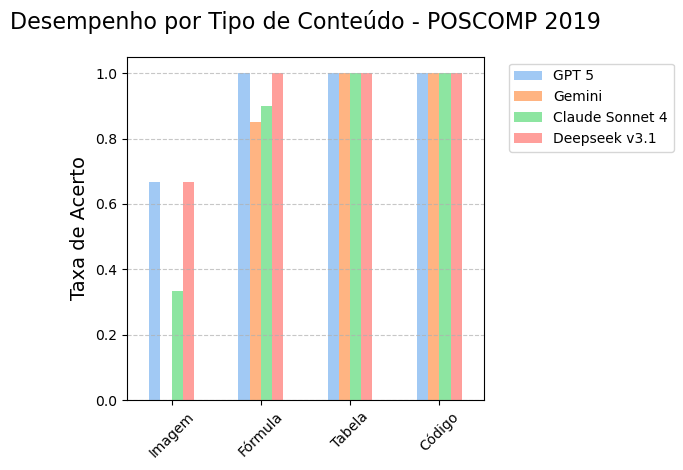

In [58]:
# baseado no que tem  na questao - imagem, formula, tabela, codigo
print("\n" + "="*60)
print("ANÁLISE POR TIPO DE CONTEÚDO")
print("="*60)

tipos_conteudo = ['Contem Imagem', 'Contem Formula', 'Contem Tabela', 'Contem Codigo']
nomes = ['Imagem', 'Fórmula', 'Tabela', 'Código']
desempenho_tipos = pd.DataFrame(index=nomes, columns=modelos)

for i, tipo in enumerate(tipos_conteudo):
    subset = df_2019[df_2019[tipo] == 1]
    print(f"\nTipo: {nomes[i]} ({len(subset)} questões)")
    for modelo in modelos:
        if len(subset) > 0:
            acertos = (subset[modelo] == subset['Gabarito']).sum()
            taxa = acertos / len(subset)
            desempenho_tipos.loc[nomes[i], modelo] = taxa
            print(f"  {modelo}: {acertos}/{len(subset)} = {taxa:.2%}")
        else:
            desempenho_tipos.loc[nomes[i], modelo] = 0
            print(f"  {modelo}: 0/0 = N/A")

            

plt.figure(figsize=(14, 8))
desempenho_tipos.plot(kind='bar')
plt.ylabel('Taxa de Acerto', fontsize=14)
plt.title('Desempenho por Tipo de Conteúdo - POSCOMP 2019', fontsize=16, pad=20)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'desempenho_por_tipo_conteudo_2019.png', 
            dpi=300, bbox_inches='tight')
plt.savefig(dir_graficos / '03_desempenho_por_conteudo' / 'desempenho_por_tipo_conteudo_2019.pdf', 
            bbox_inches='tight')
plt.show()